In [13]:
import os
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
from matplotlib import pyplot as plt
from virtualship.models import Expedition
from virtualship.utils import expedition_cost, PROJECTION, _calc_sail_time
from virtualship.expedition.simulate_schedule import simulate_schedule

In [14]:
# load expedition YAML files

groups = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K"]
group_yamls = [f"expeditions/expedition_{grp}.yaml" for grp in groups]

expeditions = [Expedition.from_yaml(yml) for yml in group_yamls if os.path.exists(yml)]

In [15]:
# global map of expedition locations

valid_groups = [grp for grp, yml in zip(groups, group_yamls) if os.path.exists(yml)]

waypoint_locations = {}
for group, exp in zip(valid_groups, expeditions):
    waypoint_locations[group] = []
    for waypoint in exp.schedule.waypoints:
        waypoint_locations[group].append(
            (waypoint.location.latitude, waypoint.location.longitude)
        )


def global_plot(waypoint_locations: dict, w: float = 10, h: float = 5) -> None:
    fig = plt.figure(figsize=(w, h), dpi=270)
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())

    ax.set_global()
    ax.stock_img()
    ax.coastlines(linewidth=0.5)

    # add waypoint locations
    for group, locations in waypoint_locations.items():
        lats, lons = zip(*locations)
        ax.plot(
            lons,
            lats,
            linewidth=2.5,
            transform=ccrs.PlateCarree(),
            label=f"Group {group}",
        )

    ax.legend(loc="lower left", fontsize=8)

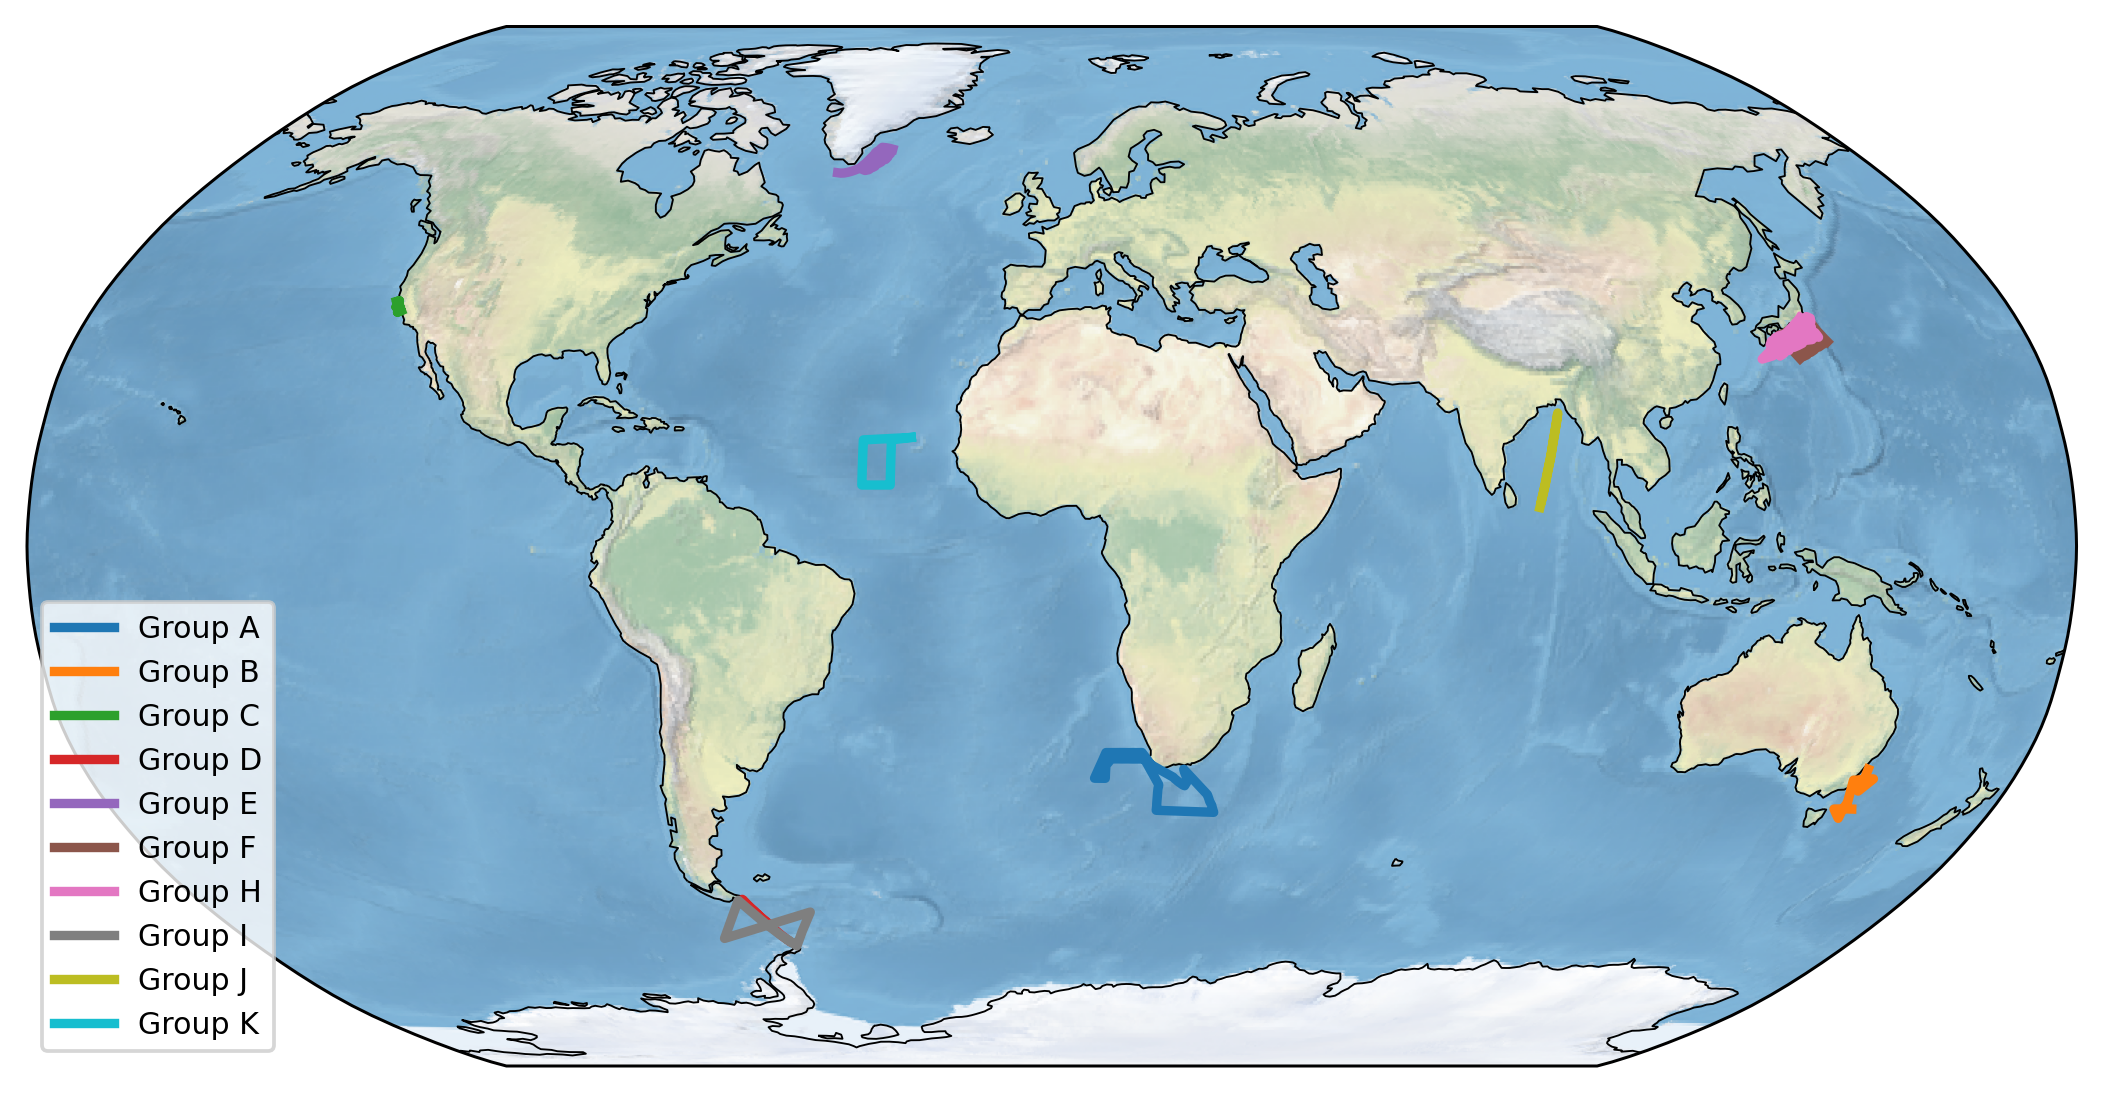

In [16]:
global_plot(waypoint_locations)

In [17]:
# prescribed ship time [days]
prescribed_time = {
    "A": 20,
    "B": 16,
    "C": 10,
    "D": 7,
    "E": 14,
    "F": 14,
    "G": 12,
    "H": 12,
    "I": 12,
    "J": 14,
    "K": 14,
}

In [18]:
# get stats

SECONDS_IN_DAY = 86400

# times
years = [expedition.schedule.waypoints[-1].time.year for expedition in expeditions]
durations = [
    (
        expedition.schedule.waypoints[-1].time - expedition.schedule.waypoints[0].time
    ).total_seconds()
    / SECONDS_IN_DAY
    for expedition in expeditions
]  # [days]

# costs
schedule_simulations = [
    simulate_schedule(PROJECTION, expedition) for expedition in expeditions
]
time_passed = [
    srs.time - expedition.schedule.waypoints[0].time
    for srs, expedition in zip(schedule_simulations, expeditions)
]
costs = [
    expedition_cost(srs, tp) for srs, tp in zip(schedule_simulations, time_passed)
]  # [USD]

# cumulative distance travelled []
distances = []
for expedition in expeditions:
    cumulative_distance = 0.0
    for i in range(1, len(expedition.schedule.waypoints)):
        prev_wp = expedition.schedule.waypoints[i - 1]
        curr_wp = expedition.schedule.waypoints[i]
        sail_time, _, ship_speed_meters_per_second = _calc_sail_time(
            prev_wp.location,
            curr_wp.location,
            expedition.ship_config.ship_speed_knots,
            PROJECTION,
        )
        cumulative_distance += sail_time.total_seconds() * ship_speed_meters_per_second
    distances.append(cumulative_distance / 1000.0)  # convert to kilometers

In [19]:
# make DataFrame

valid_groups = [grp for grp, yml in zip(groups, group_yamls) if os.path.exists(yml)]

data = {
    "Group": valid_groups,
    "Year": years,
    "Duration (days)": durations,
    "Total cost (USD)": costs,
    "Cost per day (USD)": [
        cost / duration if duration > 0 else np.nan
        for cost, duration in zip(costs, durations)
    ],
    "Distance (km)": distances,
    "Prescribed Time (days)": [prescribed_time[grp] for grp in valid_groups],
}


df = pd.DataFrame(data)

# any groups missing? append to df as NaN values
missing_groups = [grp for grp in groups if grp not in valid_groups]
missing_rows = [
    {
        "Group": grp,
        "Year": "-",
        "Duration (days)": np.nan,
        "Total cost (USD)": np.nan,
        "Cost per day (USD)": np.nan,
        "Distance (km)": np.nan,
        "Prescribed Time (days)": prescribed_time[grp],
    }
    for grp in missing_groups
]

if missing_rows:
    df = pd.concat([df, pd.DataFrame(missing_rows)], ignore_index=True)

# sort by group
df = df.sort_values(by="Group").reset_index(drop=True)

In [20]:
df

,Group,Year,Duration (days),Total cost (USD),Cost per day (USD),Distance (km),Prescribed Time (days)
0,A,2025,19.188194,575645.0,29999.956571,6350.703883,20
1,B,2025,6.577083,273354.0,41561.583782,2155.898639,16
2,C,2022,10.387500,355166.0,34191.672684,971.909499,10
3,D,2023,4.154861,125687.0,30250.590005,1265.849219,7
4,E,2012,8.312500,340395.0,40949.774436,2285.681472,14
5,F,2023,13.750000,548541.0,39893.890909,4068.235863,14
6,G,-,NaN,NaN,NaN,NaN,12
7,H,2021,14.359722,506833.0,35295.459909,5509.370842,12
8,I,2025,11.339583,365187.0,32204.622451,3816.014652,12
9,J,2025,9.916667,523541.0,52794.050420,3259.985794,14


In [21]:
# plot func


def plot_duration(
    df: pd.DataFrame,
    w: float = 14.0,
    h: float = 7.0,
    threshold_on: bool = True,
    colour_on: bool = True,
):
    """
    Generates a bar plot showing the expedition duration for each group
    relative to the ship time threshold.
    """

    groups_keys = df["Group"].tolist()
    groups_durations = df["Duration (days)"].tolist()
    groups_prescribed_time = df["Prescribed Time (days)"].tolist()

    # bar colors dependent on whether above or below ship time threshold
    if colour_on:
        bar_colors = [
            "crimson" if value > threshold else "mediumseagreen"
            for value, threshold in zip(groups_durations, groups_prescribed_time)
        ]
    else:
        bar_colors = "dodgerblue"
    # fig
    _, ax = plt.subplots(nrows=1, ncols=1, figsize=(w, h), dpi=90)

    # bars
    ax.bar(
        groups_keys,
        groups_durations,
        color=bar_colors,
        edgecolor="k",
        linewidth=1.0,
        zorder=3,
        width=0.7,
    )

    # labels and title
    ax.set_ylabel("Days", fontsize=15)
    ax.set_title("Expedition Duration", fontsize=20)

    # customise ticks
    group_names = [f"Group {grp}" for grp in groups_keys]
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(group_names, ha="center", fontsize=15)
    ax.tick_params(axis="y", labelsize=15)

    # set y-limit based on the maximum valid value
    max_duration = np.nanmax(groups_prescribed_time) if groups_prescribed_time else 0
    ax.set_ylim(0, max_duration + 0.5)

    # grid
    ax.set_facecolor("gainsboro")
    ax.grid(axis="y", linestyle="-", alpha=1.0, color="white")

    # step-wise threshold line across all groups
    if threshold_on:
        ax.plot(
            groups_keys,
            groups_prescribed_time,
            color="k",
            linestyle="--",
            linewidth=2.5,
            label="Ship-time limit",
            zorder=5,
            drawstyle="steps-mid",
        )
        plt.legend(fontsize=15, loc="best")

    plt.tight_layout()
    plt.show()

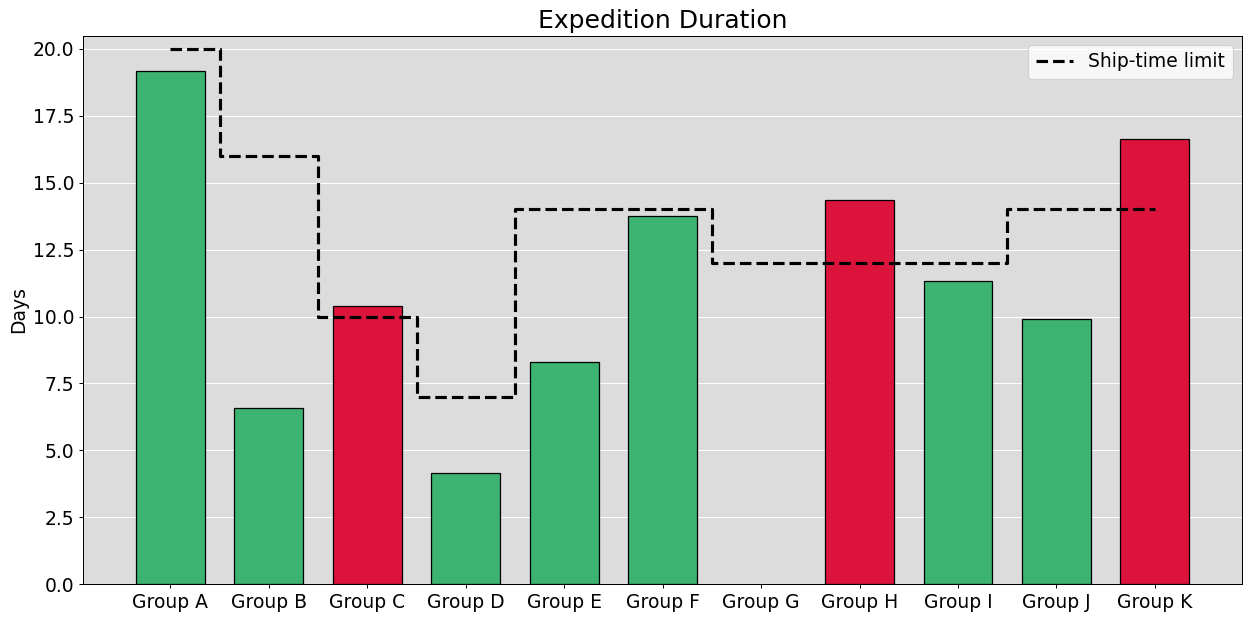

In [22]:
# plot

plot_duration(df, threshold_on=True, colour_on=True)

In [23]:
# plot func


def plot_cost(
    df: pd.DataFrame, w: float = 14.0, h: float = 7.0, highlight_on: bool = True
):
    """Generates a bar plot showing the expedition cost / per day for each group"""

    groups_keys = df["Group"].tolist()
    groups_cost_per_day = df["Cost per day (USD)"].tolist()

    # bar colors: highlight highest if enabled
    if highlight_on:
        max_idx = np.nanargmax(groups_cost_per_day)
        bar_colors = [
            "orange" if i == max_idx else "dodgerblue"
            for i in range(len(groups_cost_per_day))
        ]
    else:
        bar_colors = "dodgerblue"

    # fig
    _, ax = plt.subplots(nrows=1, ncols=1, figsize=(w, h), dpi=90)

    # bars
    ax.bar(
        groups_keys,
        groups_cost_per_day,
        color=bar_colors,
        edgecolor="k",
        linewidth=1.0,
        zorder=3,
        width=0.7,
    )

    # labels and title
    ax.set_title("Expedition Cost per Day", fontsize=20)

    # customise ticks
    group_names = [f"Group {grp}" for grp in groups_keys]
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(group_names, ha="center", fontsize=15)
    ax.tick_params(axis="y", labelsize=15)
    ax.yaxis.set_major_formatter("${x:1.2f}")

    # set y-limit based on the maximum valid value
    max_costs = np.nanmax(groups_cost_per_day) if groups_cost_per_day else 0
    ax.set_ylim(0, max_costs + 2500)

    # grid
    ax.set_facecolor("gainsboro")
    ax.grid(axis="y", linestyle="-", alpha=1.0, color="white")

    plt.tight_layout()
    plt.show()

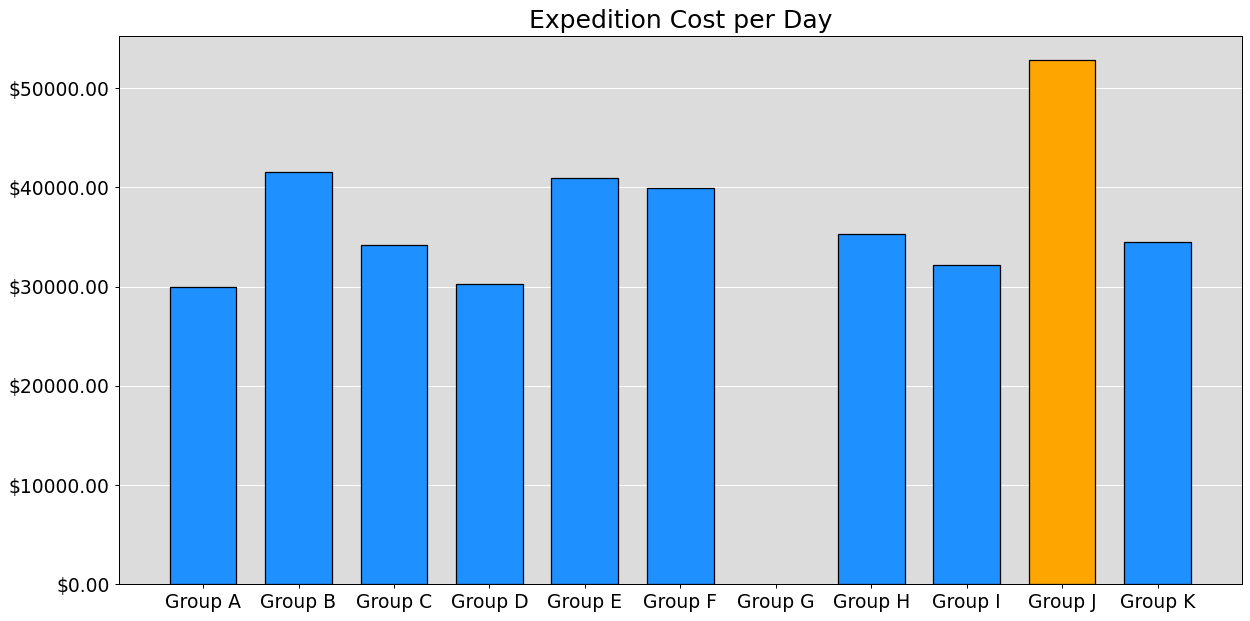

In [24]:
# plot costs

plot_cost(df, highlight_on=True)